In [213]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve,auc

In [214]:
df=pd.read_csv("customer_churn_dataset-training-master.csv")

In [215]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [216]:
df.isna().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [217]:
df=df.dropna()

In [218]:
df.isna().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [219]:
df.shape

(440832, 12)

In [220]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440832 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 43.7+ MB


In [222]:
df=df.drop('CustomerID',axis=1)

In [223]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [224]:
df['Subscription Type'].unique()

array(['Standard', 'Basic', 'Premium'], dtype=object)

In [225]:
df['Contract Length'].unique()

array(['Annual', 'Monthly', 'Quarterly'], dtype=object)

In [226]:
obj_col=df.select_dtypes(include='object').columns
obj_col

Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')

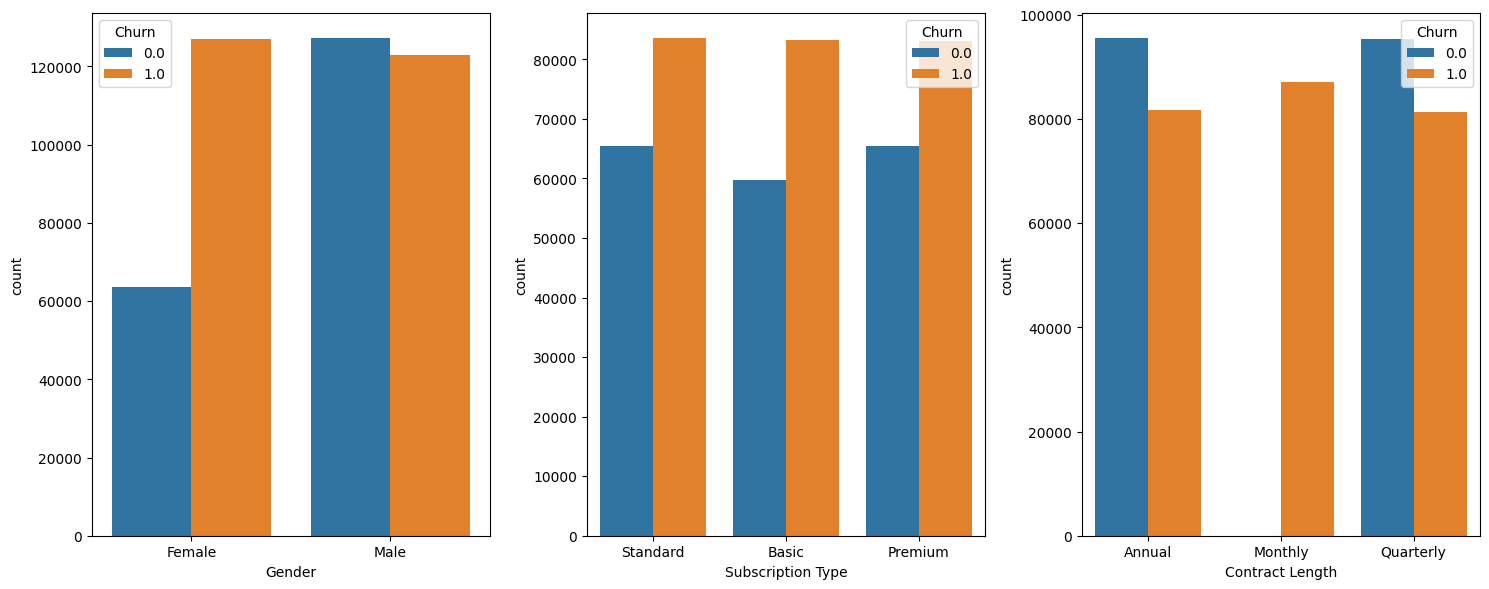

In [227]:
plt.figure(figsize=(15,6))
for i,col in enumerate(obj_col,1):
  plt.subplot(1,3,i)
  sns.countplot(data=df,x=col,hue='Churn')
plt.tight_layout()
plt.show()


In [228]:
number_col=df.select_dtypes(include='float64').columns
number_col

Index(['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay',
       'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

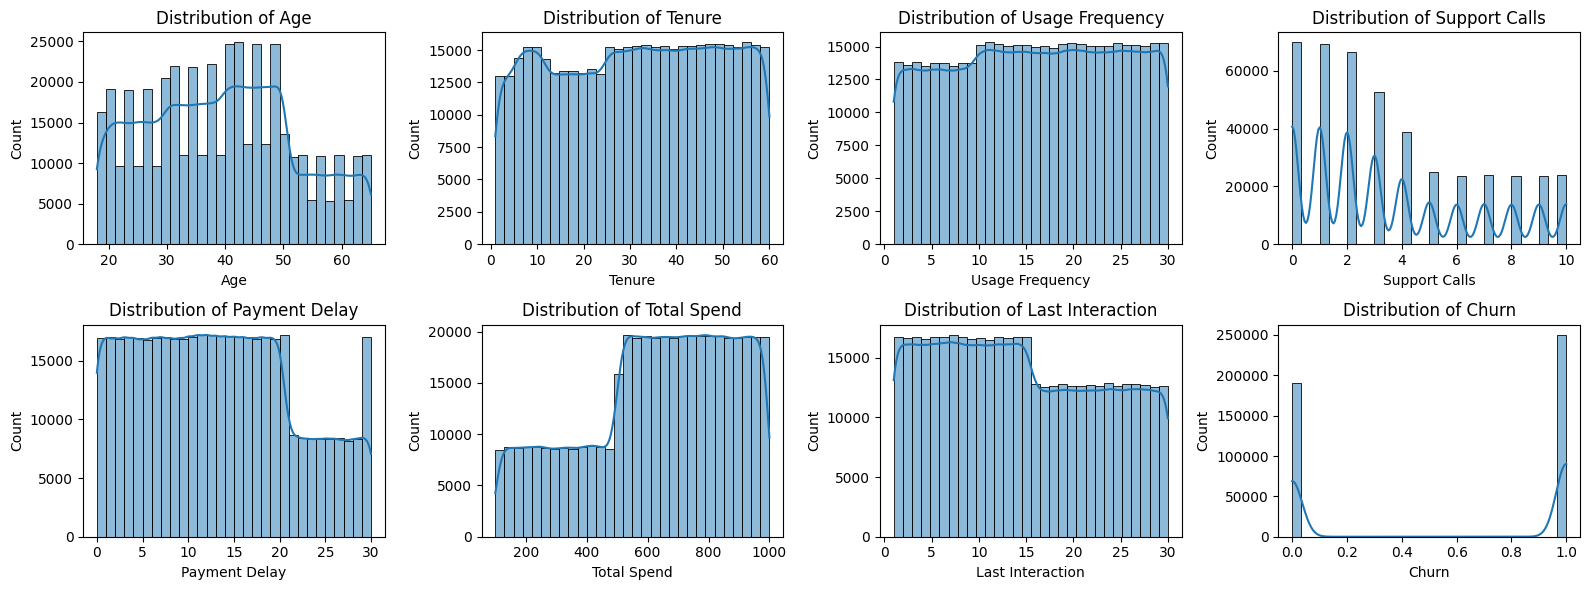

In [229]:
plt.figure(figsize=(16,6))
for i,col in enumerate(number_col,1):
  plt.subplot(2,4,i)
  sns.histplot(data=df,x=col,kde=True,bins=30)
  plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [230]:
dummies_gender=pd.get_dummies(df['Gender'],drop_first=True).astype(int)
dummies_gender

,Male
0,0
1,0
2,0
3,1
4,1
...,...
440828,1
440829,0
440830,1
440831,1


In [231]:
dummies_subscription=pd.get_dummies(df['Subscription Type'],drop_first=True).astype(int)
dummies_subscription

,Premium,Standard
0,0,1
1,0,0
2,0,0
3,0,1
4,0,0
...,...,...
440828,1,0
440829,1,0
440830,0,1
440831,0,1


In [232]:
dummies_contract=pd.get_dummies(df['Contract Length'],drop_first=True).astype(int)
dummies_contract

,Monthly,Quarterly
0,0,0
1,1,0
2,0,1
3,1,0
4,1,0
...,...,...
440828,0,0
440829,0,0
440830,0,1
440831,0,1


In [233]:
df=pd.concat([df,dummies_gender,dummies_subscription,dummies_contract],axis=1)
df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Male,Premium,Standard,Monthly,Quarterly
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0,0,0,1,0,0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0,0,0,0,1,0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0,0,0,0,0,1
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0,1,0,1,1,0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0,1,1,0,0,0
440829,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0,0,1,0,0,0
440830,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0,1,0,1,0,1
440831,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0,1,0,1,0,1


In [234]:
df.drop(['Gender','Subscription Type','Contract Length'],axis=1,inplace=True)

In [235]:
df

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Male,Premium,Standard,Monthly,Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.00,17.0,1.0,0,0,1,0,0
1,65.0,49.0,1.0,10.0,8.0,557.00,6.0,1.0,0,0,0,1,0
2,55.0,14.0,4.0,6.0,18.0,185.00,3.0,1.0,0,0,0,0,1
3,58.0,38.0,21.0,7.0,7.0,396.00,29.0,1.0,1,0,1,1,0
4,23.0,32.0,20.0,5.0,8.0,617.00,20.0,1.0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,54.0,15.0,1.0,3.0,716.38,8.0,0.0,1,1,0,0,0
440829,25.0,8.0,13.0,1.0,20.0,745.38,2.0,0.0,0,1,0,0,0
440830,26.0,35.0,27.0,1.0,5.0,977.31,9.0,0.0,1,0,1,0,1
440831,28.0,55.0,14.0,2.0,0.0,602.55,2.0,0.0,1,0,1,0,1


In [236]:
x = df.drop(['Churn', 'Last Interaction', 'Payment Delay'], axis=1)
y = df['Churn']

In [237]:
y=df['Churn']
y

,Churn
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
440828,0.0
440829,0.0
440830,0.0
440831,0.0


In [238]:
sc=StandardScaler()

In [239]:
x_train_scaled=sc.fit_transform(x_train)
x_test_scaled=sc.transform(x_test)

In [240]:
x_train_scaled

array([[-0.59313429,  1.66657762,  0.48619241, ..., -0.714763  ,
         2.01692153, -0.81654964],
       [ 1.497378  ,  0.10157417, -1.37686429, ...,  1.39906515,
        -0.49580511, -0.81654964],
       [-0.1911127 , -0.94176146,  1.41772077, ...,  1.39906515,
        -0.49580511,  1.22466529],
       ...,
       [ 0.05010026,  1.1449098 , -1.72618743, ..., -0.714763  ,
        -0.49580511, -0.81654964],
       [-0.67353861,  0.15953726, -0.91110012, ...,  1.39906515,
        -0.49580511,  1.22466529],
       [-1.23636884,  1.43472525, -0.21245385, ..., -0.714763  ,
        -0.49580511,  1.22466529]])

In [241]:
y_train

,Churn
221488,1.0
103741,1.0
205573,1.0
49722,1.0
393459,0.0
...,...
212190,1.0
216561,1.0
299056,0.0
28320,1.0


**LOGISTIC REGRESSION**

In [242]:
lr=LogisticRegression()


In [243]:
lr.fit(x_train_scaled,y_train)

LogisticRegression()

In [244]:
lr.predict(x_train_scaled)

array([1., 1., 0., ..., 0., 1., 0.])

In [245]:
lr.score(x_train_scaled,y_train)

0.8788141720896602

In [246]:
lr.score(x_test_scaled,y_test)

0.8797849535540508

<Axes: >

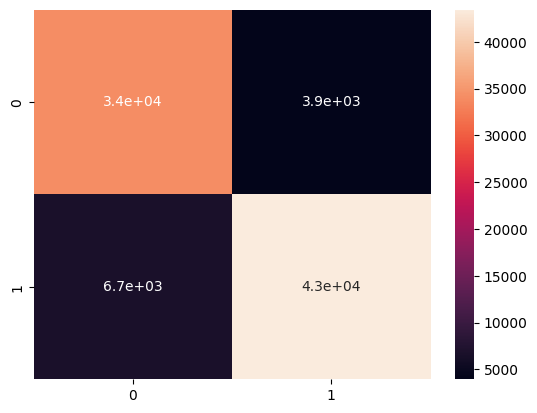

In [247]:
y_pred_lr=lr.predict(x_test_scaled)
cm=confusion_matrix(y_test,y_pred_lr)
sns.heatmap(cm,annot=True)


In [248]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87     38067
         1.0       0.92      0.87      0.89     50100

    accuracy                           0.88     88167
   macro avg       0.88      0.88      0.88     88167
weighted avg       0.88      0.88      0.88     88167



**RANDOM FOREST**

In [249]:
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [250]:
rf.score(x_train,y_train)

0.9999574667177066

In [251]:
rf.score(x_test,y_test)

0.975342248233466

<Axes: >

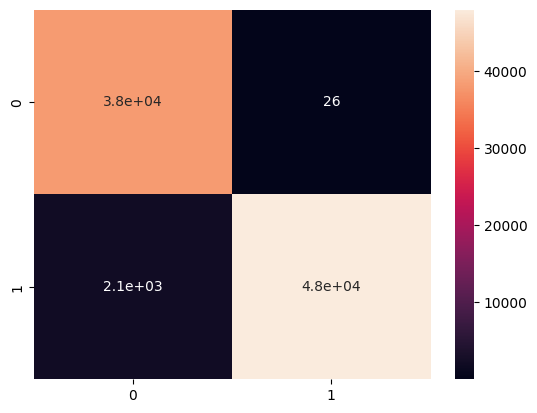

In [252]:
y_pred_rf=rf.predict(x_test)
cm=confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm,annot=True)


In [253]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     38067
         1.0       1.00      0.96      0.98     50100

    accuracy                           0.98     88167
   macro avg       0.97      0.98      0.98     88167
weighted avg       0.98      0.98      0.98     88167



<Axes: xlabel='Importance', ylabel='Feature'>

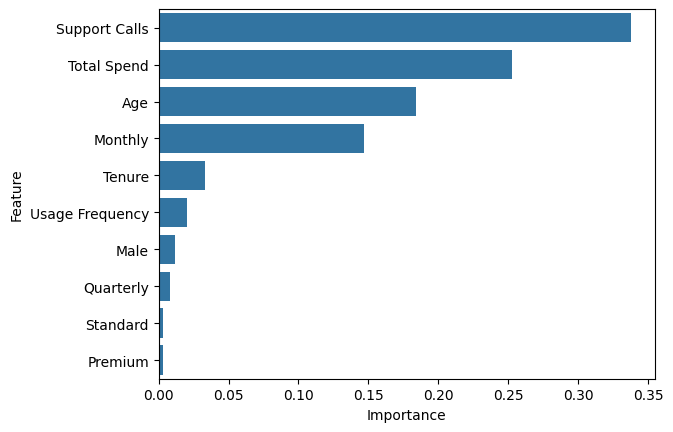

In [254]:
important=pd.DataFrame(
    {
        'Feature':x.columns,
        'Importance':rf.feature_importances_
    })
important=important.sort_values('Importance',ascending=False)
sns.barplot(data=important,x='Importance',y='Feature')

**DECISION TREE**

In [255]:

dr=DecisionTreeClassifier()
dr.fit(x_train,y_train)

DecisionTreeClassifier()

In [256]:
dr.predict(x_train)

array([1., 1., 1., ..., 0., 1., 0.])

In [257]:
dr.score(x_test,y_test)

0.9503782594394729

<Axes: >

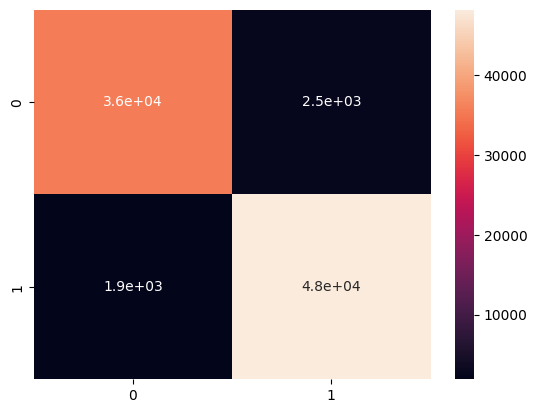

In [258]:
y_pred_dr=dr.predict(x_test)
cm=confusion_matrix(y_test,y_pred_dr)
sns.heatmap(cm,annot=True)


In [259]:
print(classification_report(y_test,y_pred_dr))

              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94     38067
         1.0       0.95      0.96      0.96     50100

    accuracy                           0.95     88167
   macro avg       0.95      0.95      0.95     88167
weighted avg       0.95      0.95      0.95     88167



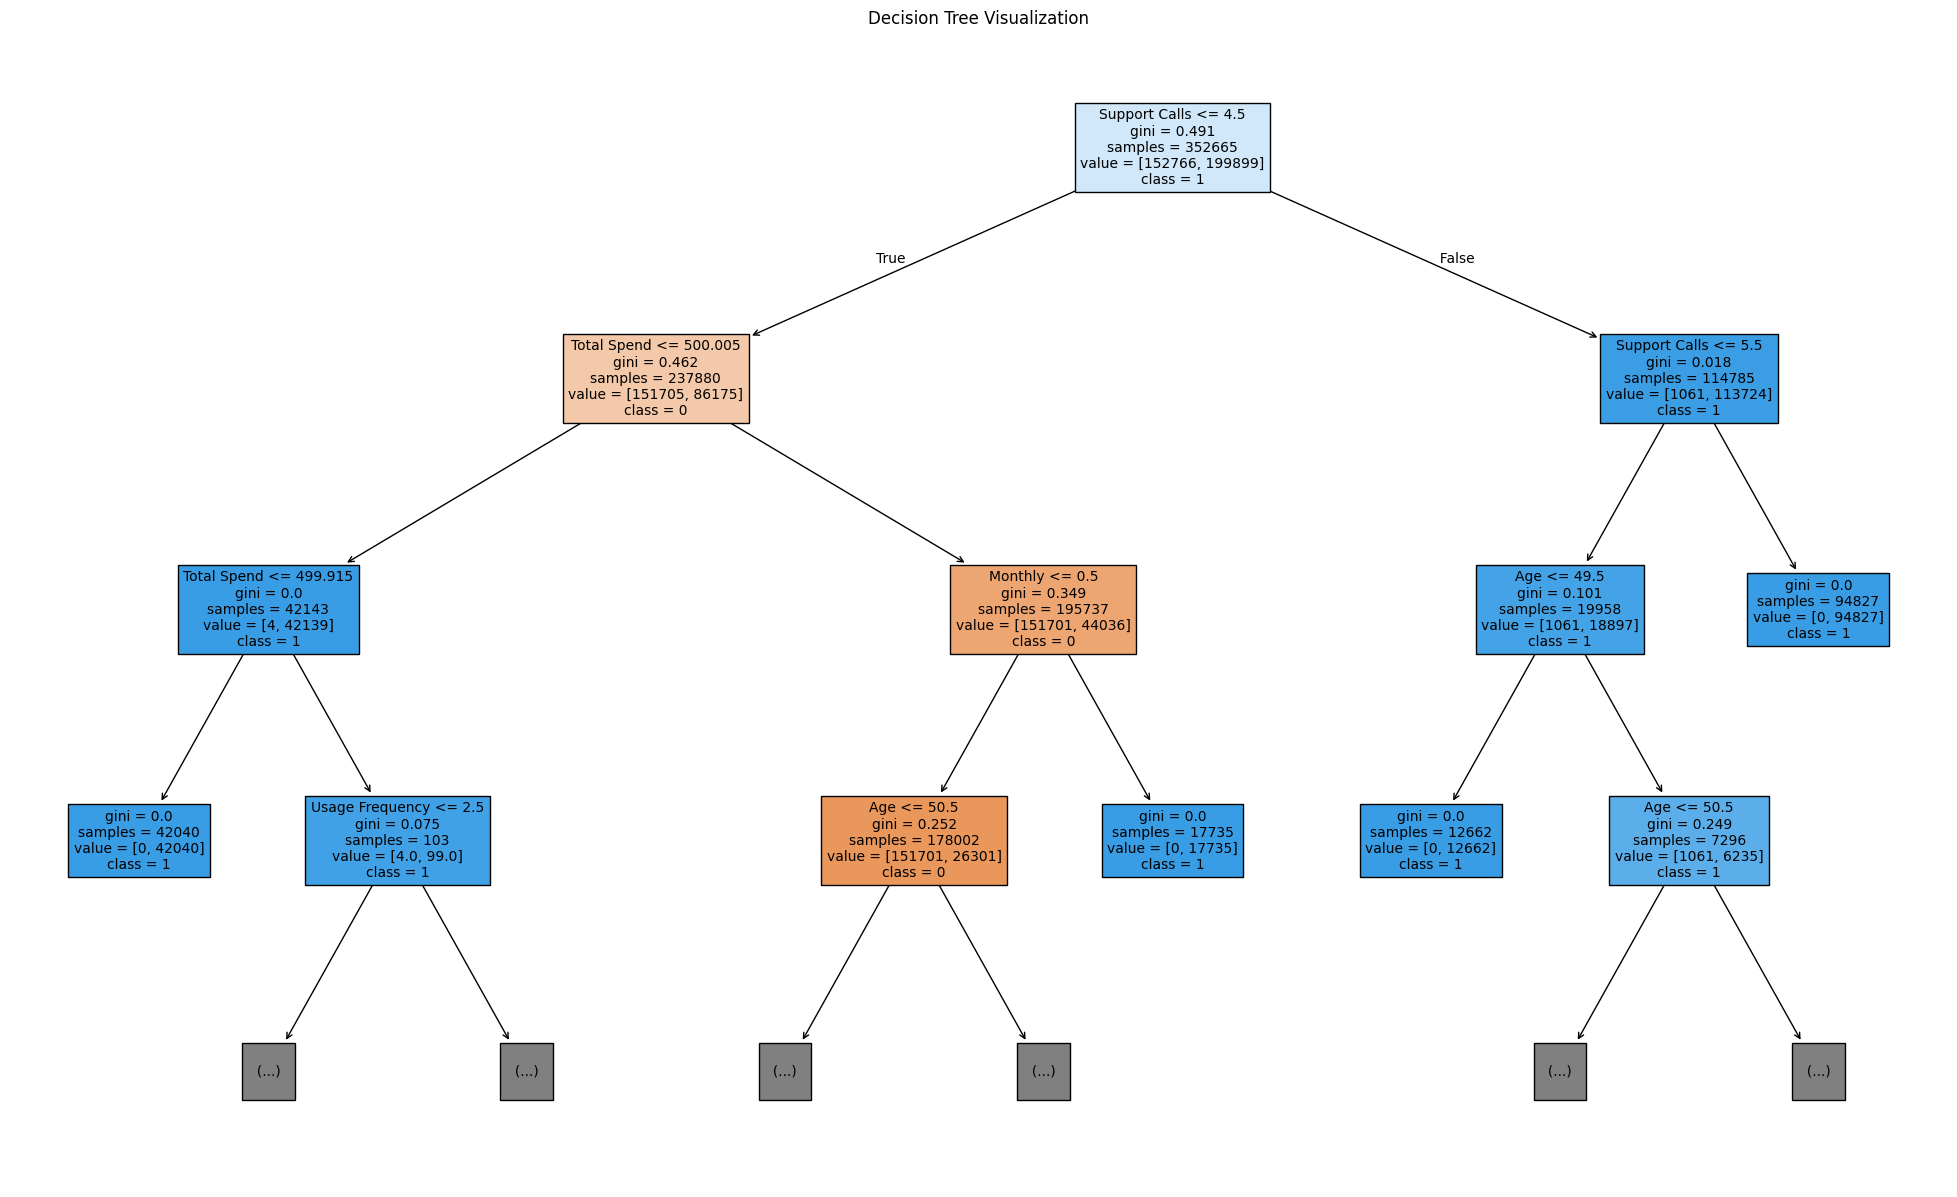

In [279]:
plt.figure(figsize=(25,15))
plot_tree(dr,feature_names=x.columns,class_names=['0','1'],filled=True,fontsize=10,max_depth=3)
plt.title("Decision Tree Visualization")
plt.show()

**XGBOOST**

In [262]:
!pip install xgboost

In [263]:
xg=XGBClassifier()
xg.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [264]:
xg.score(x_test,y_test)

0.9756371431487971

<Axes: >

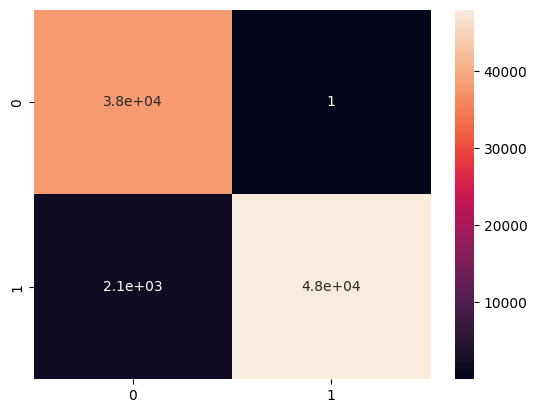

In [265]:
y_pred_xg=xg.predict(x_test)
cm=confusion_matrix(y_test,y_pred_xg)
sns.heatmap(cm,annot=True)


In [266]:
print(classification_report(y_test,y_pred_xg))

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     38067
         1.0       1.00      0.96      0.98     50100

    accuracy                           0.98     88167
   macro avg       0.97      0.98      0.98     88167
weighted avg       0.98      0.98      0.98     88167



**MODEL COMPARISON**

Text(0.5, 1.0, 'Compariosn among different models')

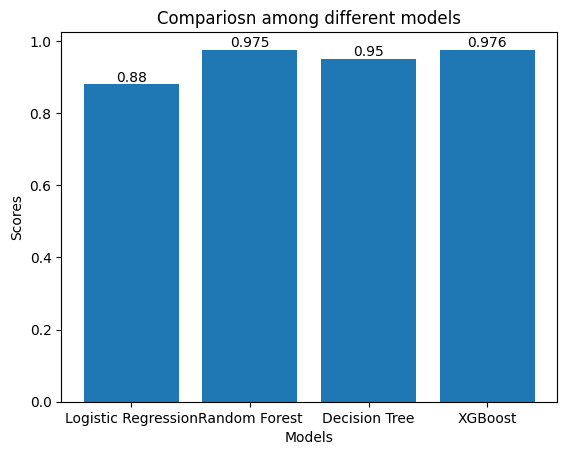

In [267]:
models=['Logistic Regression','Random Forest','Decision Tree','XGBoost']
scores=[lr.score(x_test_scaled,y_test),rf.score(x_test,y_test),dr.score(x_test,y_test),xg.score(x_test,y_test)]
bars=plt.bar(models,scores)
for bar in bars:
  yval=bar.get_height()
  plt.text((bar.get_x()+bar.get_width()/2),yval,round(yval,3),ha='center',va='bottom')
plt.xlabel("Models")
plt.ylabel("Scores")
plt.title("Compariosn among different models")

In [268]:
results=pd.DataFrame(
    {
        'Models':['Logistic Regression','Random Forest','Decision Tree','XGBoost'],
        'Accuracy':
        [
            accuracy_score(y_test,y_pred_lr),
            accuracy_score(y_test,y_pred_rf),
            accuracy_score(y_test,y_pred_dr),
            accuracy_score(y_test,y_pred_xg)
        ],
        'Precision':
        [
            precision_score(y_test,y_pred_lr),
            precision_score(y_test,y_pred_rf),
            precision_score(y_test,y_pred_dr),
            precision_score(y_test,y_pred_xg),
        ],
        'Reacll':
        [
            recall_score(y_test,y_pred_lr),
            recall_score(y_test,y_pred_rf),
            recall_score(y_test,y_pred_dr),
            recall_score(y_test,y_pred_xg),
        ],
        'F1 Score':
        [
            f1_score(y_test,y_pred_lr),
            f1_score(y_test,y_pred_rf),
            f1_score(y_test,y_pred_dr),
            f1_score(y_test,y_pred_xg)
        ]


    }
)
print(results)

                Models  Accuracy  Precision    Reacll  F1 Score
0  Logistic Regression  0.879785   0.916915  0.867006  0.891262
1        Random Forest  0.975342   0.999458  0.957126  0.977834
2        Decision Tree  0.950378   0.951035  0.962216  0.956592
3              XGBoost  0.975637   0.999979  0.957146  0.978094


**Hyperparameter Tuning using GridSearchCV (Decision Tree)**

In [269]:
tree=DecisionTreeClassifier()
tree_params={
    'max_depth':[5,10,15],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}
tree_grid=GridSearchCV(
    estimator=tree,
    param_grid=tree_params,
    cv=3,
    n_jobs=-1,
    scoring='accuracy'
)

tree_grid.fit(x_train,y_train)


#print best random tree parameter
print('Best parameter:')
print(tree_grid.best_params_)

print("Best Score:")
#print best random tree score
print(tree_grid.best_score_)

print("Best estimator report")
best_dr=tree_grid.best_estimator_
y_dr=best_dr.predict(x_test)
print(classification_report(y_test,y_dr))

Best parameter:
{'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 10}
Best Score:
0.9749365545205791
Best estimator report
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     38067
         1.0       1.00      0.96      0.98     50100

    accuracy                           0.98     88167
   macro avg       0.97      0.98      0.97     88167
weighted avg       0.98      0.98      0.98     88167



**Hyperparameter Tuning using GridSearchCV (Random Forest)**

In [270]:
rf_best=RandomForestClassifier()
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5]
}
rf_grid=GridSearchCV(
    estimator=rf_best,
    param_grid=rf_params,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=2
)
rf_grid.fit(x_train,y_train)

#print best random tree parameter
print('Best parameter:')
print(rf_grid.best_params_)

print("Best Score:")
#print best random tree score
print(rf_grid.best_score_)

print("Best estimator report")
best_rf=rf_grid.best_estimator_
y_rf=best_rf.predict(x_test)
print(classification_report(y_test,y_rf))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameter:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Best Score:
0.975200260870798
Best estimator report
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     38067
         1.0       1.00      0.96      0.98     50100

    accuracy                           0.98     88167
   macro avg       0.97      0.98      0.97     88167
weighted avg       0.98      0.98      0.98     88167



**Hyperparameter Tuning using GridSearchCV (XG Boost)**

In [271]:
xg=XGBClassifier()
xg_params={
    'n_estimators':[50,100],
    'max_depth':[3,5],
    'learning_rate':[0.01,0.1]
}
xg_grid=GridSearchCV(
    estimator=xg,
    param_grid=xg_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

xg_grid.fit(x_train,y_train)


#print best random tree parameter
print('Best parameter:')
print(xg_grid.best_params_)
print()
print("Best Score:")
#print best random tree score
print(xg_grid.best_score_)
print()
print("Best estimator report")
best_xg=xg_grid.best_estimator_
y_xg=best_xg.predict(x_test)
print(classification_report(y_test,y_xg))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameter:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

Best Score:
0.9749904300114839

Best estimator report
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     38067
         1.0       1.00      0.96      0.98     50100

    accuracy                           0.97     88167
   macro avg       0.97      0.98      0.97     88167
weighted avg       0.98      0.97      0.97     88167



In [272]:
best_model=pd.DataFrame(
    {
        'Models':['Random Forest','Decision Tree','XGBoost'],
        'Scores':[tree_grid.best_score_,rf_grid.best_score_,xg_grid.best_score_],
        'Parametrs':[tree_grid.best_params_,rf_grid.best_params_,xg_grid.best_params_]
    }
)
print(best_model)

          Models    Scores                                          Parametrs
0  Random Forest  0.974937  {'criterion': 'entropy', 'max_depth': 15, 'min...
1  Decision Tree  0.975200  {'max_depth': 15, 'min_samples_split': 2, 'n_e...
2        XGBoost  0.974990  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...


In [273]:
dr_prob=best_dr.predict_proba(x_test)[:,1]
rf_prob=best_rf.predict_proba(x_test)[:,1]
xg_prob=best_xg.predict_proba(x_test)[:,1]


In [274]:
dr_fpr,dr_tpr,dr_t=roc_curve(y_test,dr_prob)
rf_fpr,rf_tpr,rf_t=roc_curve(y_test,rf_prob)
xg_fpr,xg_tpr,xg_t=roc_curve(y_test,xg_prob)

dr_auc=auc(dr_fpr,dr_tpr)
rf_auc=auc(rf_fpr,rf_tpr)
xg_auc=auc(xg_fpr,xg_tpr)

In [275]:
result1=pd.DataFrame(
    {
        'Models':['Decision Tree','Random Forest','XGBoost'],
        'AUC':[dr_auc,rf_auc,xg_auc]
    }
)
print(result1)

          Models       AUC
0  Decision Tree  0.985170
1  Random Forest  0.986449
2        XGBoost  0.986084


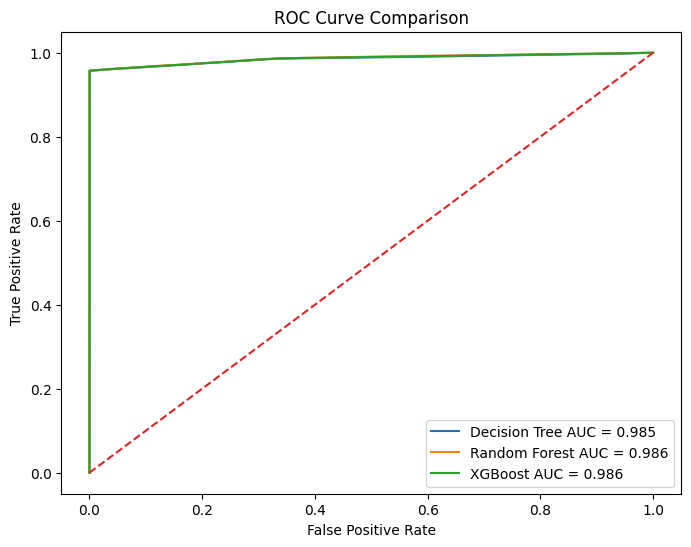

In [276]:
plt.figure(figsize=(8,6))

plt.plot(dr_fpr, dr_tpr, label=f'Decision Tree AUC = {dr_auc:.3f}')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest AUC = {rf_auc:.3f}')
plt.plot(xg_fpr, xg_tpr, label=f'XGBoost AUC = {xg_auc:.3f}')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [280]:
import pickle
with open("model.pkl","wb") as f:
  pickle.dump(best_rf,f)
